# 01 — Data Collection
**Project:** Are Retrofitted Turbines Significantly More Powerful?  
**Purpose:** Load all raw data sources, perform an initial structural inspection, and document what each file contains before any cleaning takes place.

---

## 1. Imports & Settings

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt

## 2. Load Datasets

All paths are relative to keep the repo portable.

In [10]:
# --- Primary dataset ---
turbines = pd.read_csv('../data/original/wind-turbines.csv', low_memory=False, encoding='latin-1')

# --- Operator / generation data ---
operators = pd.read_csv('../data/original/wind-operators.csv', low_memory=False)

# --- Supporting datasets ---
bills   = pd.read_csv('../data/original/average_electricity_bills.csv', thousands=',')
rates   = pd.read_csv('../data/original/average_electricity_rates.csv')
wind    = pd.read_csv('../data/original/windiest-states-in-the-us.-2025.csv')

print('All files loaded successfully.')

All files loaded successfully.


## 3. Shape & Schema Inspection

Before any transformation, we document the raw shape and dtypes of every dataset.

### 3.1 wind-turbines.csv — Primary Dataset

In [11]:
print(f'Shape: {turbines.shape}')   # (rows, cols)
turbines.head(3)

Shape: (70808, 27)


,case_id,faa_ors,faa_asn,usgs_pr_id,eia_id,t_state,t_county,t_fips,p_name,p_year,p_tnum,p_cap,t_manu,t_model,t_cap,t_hh,t_rd,t_rsa,t_ttlh,retrofit,retrofit_year,t_conf_atr,t_conf_loc,t_img_date,t_img_srce,xlong,ylat
0,3072661,NaN,NaN,"5,149.00","52,161.00",CA,Kern County,6029,251 Wind,"1,987.00",194,18.43,Vestas,NaN,95.00,NaN,NaN,NaN,NaN,0,NaN,2,3,5/8/2018,Digital Globe,-118.36,35.08
1,3072695,NaN,NaN,"5,143.00","52,161.00",CA,Kern County,6029,251 Wind,"1,987.00",194,18.43,Vestas,NaN,95.00,NaN,NaN,NaN,NaN,0,NaN,2,3,5/8/2018,Digital Globe,-118.36,35.08
2,3072704,NaN,NaN,"5,146.00","52,161.00",CA,Kern County,6029,251 Wind,"1,987.00",194,18.43,Vestas,NaN,95.00,NaN,NaN,NaN,NaN,0,NaN,2,3,5/8/2018,Digital Globe,-118.36,35.08


In [12]:
turbines.dtypes

case_id            int64
faa_ors              str
faa_asn              str
usgs_pr_id       float64
eia_id           float64
t_state              str
t_county             str
t_fips             int64
p_name               str
p_year           float64
p_tnum             int64
p_cap            float64
t_manu               str
t_model              str
t_cap            float64
t_hh             float64
t_rd             float64
t_rsa            float64
t_ttlh           float64
retrofit           int64
retrofit_year    float64
t_conf_atr         int64
t_conf_loc         int64
t_img_date           str
t_img_srce           str
xlong            float64
ylat             float64
dtype: object

### 3.2 wind-operators.csv

In [13]:
print(f'Shape: {operators.shape}')
operators.head(3)

Shape: (14405, 97)


,Plant Id,Combined Heat And Power Plant,Nuclear Unit Id,Plant Name,Operator Name,Operator Id,Plant State,Census Region,NERC Region,Reserved,NAICS Code,EIA Sector Number,Sector Name,Reported Prime Mover,Reported Fuel Type Code,AER/MER Fuel Type Code,Balancing Authority Code,Respondent Frequency,Physical Unit Label,Quantity January,Quantity February,Quantity March,Quantity April,Quantity May,Quantity June,Quantity July,Quantity August,Quantity September,Quantity October,Quantity November,Quantity December,Elec_Quantity January,Elec_Quantity February,Elec_Quantity March,Elec_Quantity April,Elec_Quantity May,Elec_Quantity June,Elec_Quantity July,Elec_Quantity August,Elec_Quantity September,Elec_Quantity October,Elec_Quantity November,Elec_Quantity December,MMBtuPer_Unit January,MMBtuPer_Unit February,MMBtuPer_Unit March,MMBtuPer_Unit April,MMBtuPer_Unit May,MMBtuPer_Unit June,MMBtuPer_Unit July,MMBtuPer_Unit August,MMBtuPer_Unit September,MMBtuPer_Unit October,MMBtuPer_Unit November,MMBtuPer_Unit December,Tot_MMBtu January,Tot_MMBtu February,Tot_MMBtu March,Tot_MMBtu April,Tot_MMBtu May,Tot_MMBtu June,Tot_MMBtu July,Tot_MMBtu August,Tot_MMBtu September,Tot_MMBtu October,Tot_MMBtu November,Tot_MMBtu December,Elec_MMBtu January,Elec_MMBtu February,Elec_MMBtu March,Elec_MMBtu April,Elec_MMBtu May,Elec_MMBtu June,Elec_MMBtu July,Elec_MMBtu August,Elec_MMBtu September,Elec_MMBtu October,Elec_MMBtu November,Elec_MMBtu December,Netgen January,Netgen February,Netgen March,Netgen April,Netgen May,Netgen June,Netgen July,Netgen August,Netgen September,Netgen October,Netgen November,Netgen December,Total Fuel Consumption Quantity,Electric Fuel Consumption Quantity,Total Fuel Consumption MMBtu,Elec Fuel Consumption MMBtu,Net Generation (Megawatthours),YEAR
0,90,N,.,Snake River,Nome Joint Utility Systems,13642,AK,PACN,ASCC,NaN,22,1,Electric Utility,WT,WND,WND,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,1,1,2,2,2,2,1,2,1,2,2,1,1,1,2,2,2,2,1,2,1,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,19,19,2,2015
1,508,N,.,Lamar Plant,City of Lamar - (CO),10633,CO,MTN,WECC,NaN,22,1,Electric Utility,WT,WND,WND,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"9,324","7,682","8,372","8,166","7,670","5,198","5,466","6,815","5,769","8,166","8,081","10,674","9,324","7,682","8,372","8,166","7,670","5,198","5,466","6,815","5,769","8,166","8,081","10,674","1,000",824,898,876,823,558,587,731,619,876,867,"1,145",0,0,"91,383","91,383","9,806",2015
2,692,N,.,Medicine Bow,Medicine Bow Wind LLC,59632,WY,MTN,WECC,NaN,22,1,Electric Utility,WT,WND,WND,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"16,155","14,518","13,016","9,624","8,774","5,810","7,483","7,468","9,398","10,382","16,190","18,199","16,155","14,518","13,016","9,624","8,774","5,810","7,483","7,468","9,398","10,382","16,190","18,199","1,734","1,558","1,397","1,033",942,623,803,801,"1,008","1,114","1,737","1,953",0,0,"137,017","137,017","14,703",2015


In [14]:
operators.dtypes

Plant Id                              int64
Combined Heat And Power Plant           str
Nuclear Unit Id                         str
Plant Name                              str
Operator Name                           str
                                      ...  
Electric Fuel Consumption Quantity    int64
Total Fuel Consumption MMBtu            str
Elec Fuel Consumption MMBtu             str
Net Generation (Megawatthours)          str
YEAR                                  int64
Length: 97, dtype: object

### 3.3 Supporting Datasets

In [15]:
for name, df in [('bills', bills), ('rates', rates), ('wind', wind)]:
    print(f'--- {name} ---  shape: {df.shape}')
    display(df.head(3))
    print()

--- bills ---  shape: (50, 4)


,State,Residential,Commercial,Average
0,Alabama,115.00,679.26,397.13
1,Alaska,198.10,"1,201.93",700.02
2,Arizona,118.76,645.96,382.36



--- rates ---  shape: (51, 4)


,State,Residential,Commercial,Average
0,Alabama,14.91,13.83,14.37
1,Alaska,22.38,18.43,20.41
2,Arizona,15.20,11.92,13.56



--- wind ---  shape: (50, 6)


,stateFlagCode,state,WindiestStatesAverageWindSpeedMPH,MeanWindSpeed328ft,MeanWindPower328ft,MeanWindSpeed33ft
0,NaN,South Dakota,21.32,20.30,722,12.80
1,NaN,Montana,21.03,20.50,985,13.50
2,NaN,Wyoming,20.88,21.50,964,14.10


## 4. Null Overview

A high-level count of missing values across every column — this guides the cleaning strategy in the next notebook.

In [16]:
def null_report(df, name):
    """Returns a sorted DataFrame of null counts and percentages."""
    total   = df.isnull().sum()
    pct     = (total / len(df) * 100).round(2)
    report  = pd.DataFrame({'null_count': total, 'null_pct': pct})
    report  = report[report['null_count'] > 0].sort_values('null_pct', ascending=False)
    print(f'\n=== {name} — {len(report)} columns with nulls ===')
    return report

null_report(turbines,  'wind-turbines')


=== wind-turbines — 15 columns with nulls ===


,null_count,null_pct
retrofit_year,64822,91.55
usgs_pr_id,32545,45.96
t_img_date,8316,11.74
t_ttlh,6180,8.73
t_hh,6180,8.73
t_rsa,5934,8.38
t_rd,5934,8.38
eia_id,5793,8.18
faa_ors,5792,8.18
t_model,5777,8.16


In [17]:
null_report(operators, 'wind-operators')


=== wind-operators — 5 columns with nulls ===


,null_count,null_pct
Reserved,14405,100.00
Physical Unit Label,14405,100.00
Balancing Authority Code,3138,21.78
Respondent Frequency,3048,21.16
NERC Region,213,1.48


In [18]:
for name, df in [('bills', bills), ('rates', rates), ('wind', wind)]:
    null_report(df, name)


=== bills — 0 columns with nulls ===

=== rates — 0 columns with nulls ===

=== wind — 1 columns with nulls ===


## 5. Retrofit Target Variable | First Look

Our problem statement revolves around the `retrofit` flag. We inspect its raw distribution before any cleaning is applied.

In [22]:
print('retrofit value counts (raw):')
print(turbines['retrofit'].value_counts(dropna=False))
print()
print('retrofit_year value counts (top 10):')
print(turbines['retrofit_year'].value_counts(dropna=False).head(10))

retrofit value counts (raw):
retrofit
0    64822
1     5986
Name: count, dtype: int64

retrofit_year value counts (top 10):
retrofit_year
NaN         64822
2,019.00     1893
2,020.00     1642
2,017.00     1317
2,018.00     1125
2,015.00        9
Name: count, dtype: int64


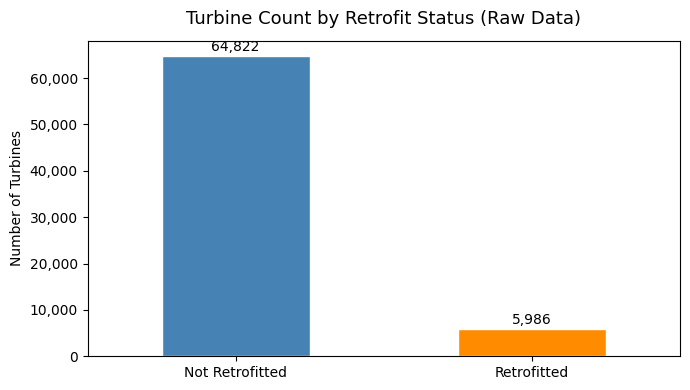

In [23]:
#bar chart | retrofitted vs non-retrofitted turbine counts
retrofit_counts = turbines['retrofit'].value_counts().rename({0: 'Not Retrofitted', 1: 'Retrofitted'})

fig, ax = plt.subplots(figsize=(7, 4))
retrofit_counts.plot(kind='bar', ax=ax, color=['steelblue', 'darkorange'], edgecolor='white', width=0.5)
ax.set_title('Turbine Count by Retrofit Status (Raw Data)', fontsize=13, pad=12)
ax.set_xlabel('')
ax.set_ylabel('Number of Turbines')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=0)

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 300,
            f'{int(bar.get_height()):,}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

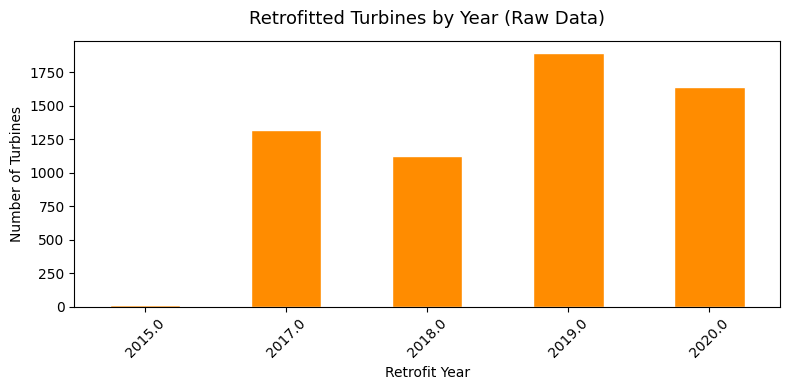

In [24]:
# Retrofit year distribution — when did retrofits happen?
retrofitted_df = turbines[turbines['retrofit'] == 1]

fig, ax = plt.subplots(figsize=(8, 4))
retrofitted_df['retrofit_year'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color='darkorange', edgecolor='white'
)
ax.set_title('Retrofitted Turbines by Year (Raw Data)', fontsize=13, pad=12)
ax.set_xlabel('Retrofit Year')
ax.set_ylabel('Number of Turbines')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Observation:** The vast majority of retrofits occurred between 2017 and 2020, with 2019 being the peak year. This will be explored further in the EDA notebook.

## 6. Key Variable Ranges — Sanity Check

A quick scan of the primary numeric columns to flag anything obviously off before cleaning begins.

In [25]:
key_cols = ['t_cap', 't_hh', 't_rd', 't_rsa', 't_ttlh', 'p_year', 'p_cap']
turbines[key_cols].describe()

,t_cap,t_hh,t_rd,t_rsa,t_ttlh,p_year,p_cap
count,"65,328.00","64,628.00","64,874.00","64,874.00","64,628.00","70,195.00","66,326.00"
mean,"1,963.53",81.05,95.66,"7,618.50",129.05,"2,011.65",170.18
std,717.07,12.03,23.42,"3,309.23",22.19,7.88,104.48
min,50.00,19.00,13.40,141.03,30.40,"1,981.00",0.05
25%,"1,500.00",80.00,82.00,"5,281.02",121.00,"2,008.00",99.00
50%,"2,000.00",80.00,100.00,"7,853.98",130.10,"2,012.00",158.00
75%,"2,300.00",87.00,110.00,"9,503.32",145.10,"2,018.00",211.22
max,"6,000.00",131.00,155.00,"18,869.19",199.60,"2,021.00",525.02


**Next step → `02_Data_Cleaning.ipynb`:** Handle nulls, fix types, engineer features, and merge all datasets into a single clean file.